In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
uber=pd.read_csv('UberDataset.csv')
uber.head(10)

In [ ]:
uber.describe()

In [ ]:
uber.info()

In [ ]:
uber.isnull().sum()

In [ ]:
uber.duplicated().sum()

In [ ]:
uber.nunique()

In [ ]:
uber['PURPOSE'].value_counts()

In [ ]:
uber['PURPOSE'].fillna(method='ffill',inplace=True)

In [ ]:
uber.head(10)

In [ ]:
uber['START_DATE'] = pd.to_datetime(uber['START_DATE'],errors='coerce')
uber['END_DATE'] = pd.to_datetime(uber['END_DATE'],errors='coerce')

In [ ]:
uber.head(10)

In [ ]:
# seperate the date and time and month and year
uber['start_date'] = uber['START_DATE'].dt.date
uber['start_time'] = uber['START_DATE'].dt.time
uber['end_date'] = uber['END_DATE'].dt.date
uber['end_time'] = uber['END_DATE'].dt.time
uber['month'] = uber['START_DATE'].dt.month
uber['year'] = uber['START_DATE'].dt.year


In [ ]:
uber.head(10)

In [ ]:
uber.head(10)

In [ ]:
uber.drop(['START_DATE','END_DATE'],axis=1,inplace=True)
uber = uber[['start_date','start_time','end_date','end_time','month','year','CATEGORY','START','STOP','MILES','PURPOSE']]

In [ ]:
uber.month.value_counts()

In [ ]:
uber.month.isnull().sum()

In [ ]:
# uber.month.fillna(fill,inplace=True)
uber['month'] = uber['month'].fillna(uber['month'].mode()[0])
uber['month'] = uber['month'].astype(int)


In [ ]:
uber.head(10)

In [ ]:
uber.month.count()

In [ ]:
uber.month.value_counts()

In [ ]:
uber['year'] = uber['year'].fillna(uber['year'].mode()[0])
uber['year'] = uber['year'].astype(int)

In [ ]:
uber.dtypes

In [ ]:
# convert start_time and end_time to hours and minutes
uber['start_hour'] = uber['start_time'].apply(lambda x: x.hour)
uber['start_minute'] = uber['start_time'].apply(lambda x: x.minute)
uber['end_hour'] = uber['end_time'].apply(lambda x: x.hour)
uber['end_minute'] = uber['end_time'].apply(lambda x: x.minute)

In [ ]:
# rearrange the columns and drop start_time and end_time columns
uber = uber[['start_date','start_hour','start_minute','end_date','end_hour','end_minute','month','year','CATEGORY','START','STOP','MILES','PURPOSE']]


In [ ]:
# create a new column for duration of the trip to be in minutes
uber['duration'] = uber['end_hour']*60 + uber['end_minute'] - (uber['start_hour']*60 + uber['start_minute'])



In [ ]:
# convert miles to km
uber['MILES'] = uber['MILES']*1.60934
#calculate speed
uber['speed'] = uber['MILES']/(uber['duration']/60)

In [ ]:
uber.head(5)

In [ ]:
uber.describe()

In [ ]:
# found problem in speed that have negative value
uber[uber["speed"]==-17.10798391304348]

In [ ]:
uber.speed.min()

In [ ]:
# plot the heatmap
plt.figure(figsize=(10,5))
sns.heatmap(uber.drop(['start_date','end_date'], axis=1).corr(numeric_only=True), annot=True)
plt.show()

In [ ]:
sns.countplot(x='month',data=uber)
plt.title(" Distrubution of Months")
plt.show()

In [ ]:
# Count the occurrences of each category
category_counts = uber['CATEGORY'].value_counts()

# Create a bar plot
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Categories')
plt.show()

In [ ]:
# Count the occurrences of each purpose
purpose_counts = uber['PURPOSE'].value_counts()

# Create a bar plot
plt.bar(purpose_counts.index, purpose_counts.values)

plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Distribution of Purpose')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.show()

In [ ]:

plt.figure(figsize=(15, 5))
sns.countplot(data=uber, x='PURPOSE', hue='CATEGORY')
plt.xticks(rotation=90)
plt.show()

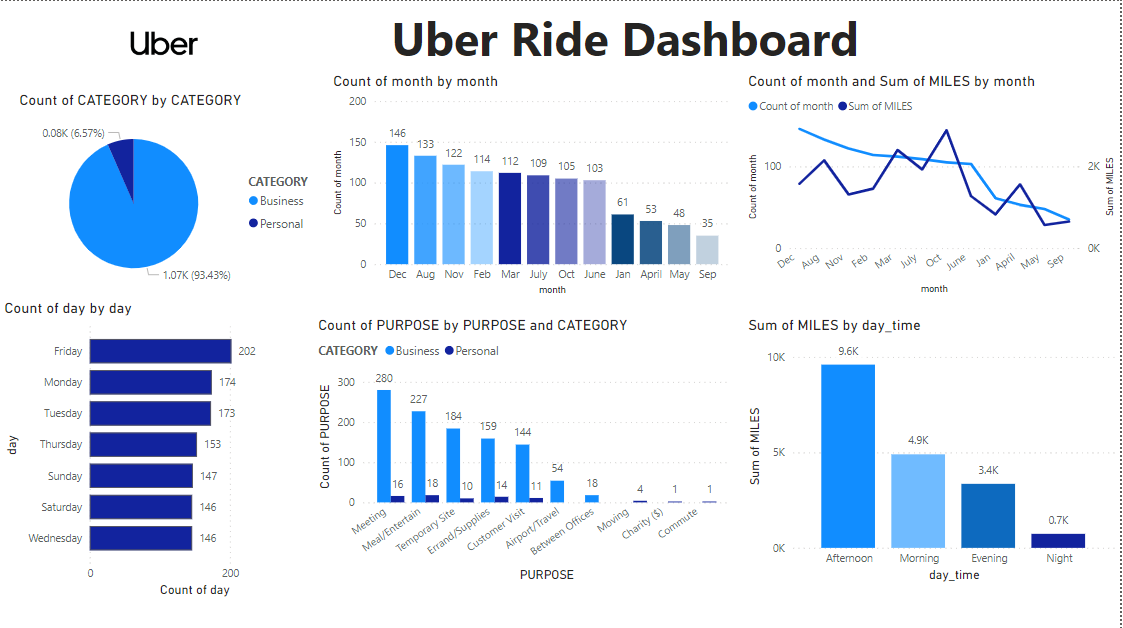